# 03 — EDA: previous_application

Análisis de las solicitudes previas de los clientes **en Home Credit** (no en otras instituciones).  
Todo el análisis se orienta al TARGET de `application_train`.

## Estructura
```
application_train (SK_ID_CURR)
    └── previous_application.csv  (SK_ID_CURR → muchas solicitudes, SK_ID_PREV por solicitud)
```

## Contenido
1. CSV → Parquet
2. Shape y estructura
3. Valores faltantes
4. STATUS de contratos y tasa de default
5. Aggregaciones por SK_ID_CURR
6. Correlación con TARGET
7. KDE por TARGET — top features
8. Resumen

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_style('white')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 10

COLOR_0 = "#000986"   
COLOR_1 = "#fc1c03" 

ROOT      = os.path.abspath(os.path.join('..', '..'))
DATA_RAW  = os.path.join(ROOT, 'data', 'raw')
DATA_PROC = os.path.join(ROOT, 'data', 'processed')

os.makedirs(DATA_PROC, exist_ok=True)

## 1. CSV → Parquet

In [2]:
PREV_PARQ = os.path.join(DATA_PROC, 'previous_application.parquet')

if not os.path.exists(PREV_PARQ):
    print('Convirtiendo previous_application.csv → parquet ...')
    prev = pd.read_csv(os.path.join(DATA_RAW, 'previous_application.csv'))
    prev.to_parquet(PREV_PARQ, index=False)
    print(f'  Guardado: {PREV_PARQ}')
else:
    print('previous_application.parquet ya existe.')

Convirtiendo previous_application.csv → parquet ...
  Guardado: c:\Users\HP\OneDrive\Escritorio\David Guzzi\Github\MECMT07\data\processed\previous_application.parquet


## 2. Carga y estructura

In [3]:
prev  = pd.read_parquet(PREV_PARQ)
train = pd.read_parquet(os.path.join(DATA_PROC, 'app_train.parquet'))[['SK_ID_CURR', 'TARGET']]

print(f'previous_application: {prev.shape[0]:>8,} filas × {prev.shape[1]} columnas')
print(f'Clientes únicos     : {prev["SK_ID_CURR"].nunique():>8,}')
print(f'Solicitudes únicas  : {prev["SK_ID_PREV"].nunique():>8,}')

# Tipos
num_cols = prev.select_dtypes(include=np.number).columns.tolist()
cat_cols = prev.select_dtypes(include='object').columns.tolist()
print(f'\nNuméricas: {len(num_cols)} | Categóricas: {len(cat_cols)}')
display(prev.head(3))

previous_application: 1,670,214 filas × 37 columnas
Clientes únicos     :  338,857
Solicitudes únicas  : 1,670,214

Numéricas: 21 | Categóricas: 16


,SK_ID_PREV,SK_ID_CURR,NAME_CONTRACT_TYPE,AMT_ANNUITY,AMT_APPLICATION,AMT_CREDIT,AMT_DOWN_PAYMENT,AMT_GOODS_PRICE,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,...,NAME_SELLER_INDUSTRY,CNT_PAYMENT,NAME_YIELD_GROUP,PRODUCT_COMBINATION,DAYS_FIRST_DRAWING,DAYS_FIRST_DUE,DAYS_LAST_DUE_1ST_VERSION,DAYS_LAST_DUE,DAYS_TERMINATION,NFLAG_INSURED_ON_APPROVAL
0,2030495,271877,Consumer loans,1730.430,17145.0,17145.0,0.0,17145.0,SATURDAY,15,...,Connectivity,12.0,middle,POS mobile with interest,365243.0,-42.0,300.0,-42.0,-37.0,0.0
1,2802425,108129,Cash loans,25188.615,607500.0,679671.0,NaN,607500.0,THURSDAY,11,...,XNA,36.0,low_action,Cash X-Sell: low,365243.0,-134.0,916.0,365243.0,365243.0,1.0
2,2523466,122040,Cash loans,15060.735,112500.0,136444.5,NaN,112500.0,TUESDAY,11,...,XNA,12.0,high,Cash X-Sell: high,365243.0,-271.0,59.0,365243.0,365243.0,1.0


## 3. Valores faltantes

In [4]:
miss_pct = prev.isnull().mean().mul(100).round(2).sort_values(ascending=False)
miss_pct = miss_pct[miss_pct > 0]
print(f'Columnas con NA: {len(miss_pct)} de {prev.shape[1]}')
print(f'  Con >90% NA : {(miss_pct > 90).sum()}')
display(miss_pct.to_frame('% NA').head(15))

Columnas con NA: 15 de 37
  Con >90% NA : 2


,% NA
RATE_INTEREST_PRIVILEGED,99.64
RATE_INTEREST_PRIMARY,99.64
AMT_DOWN_PAYMENT,53.64
RATE_DOWN_PAYMENT,53.64
NAME_TYPE_SUITE,49.12
DAYS_TERMINATION,40.30
DAYS_FIRST_DRAWING,40.30
DAYS_FIRST_DUE,40.30
DAYS_LAST_DUE_1ST_VERSION,40.30
DAYS_LAST_DUE,40.30


## 4. NAME_CONTRACT_STATUS y tasa de default

El status de las solicitudes previas (Approved/Refused/Canceled) es muy informativo.

NAME_CONTRACT_STATUS — distribución:
NAME_CONTRACT_STATUS
Approved        1036781
Canceled         316319
Refused          290678
Unused offer      26436
Name: count, dtype: int64


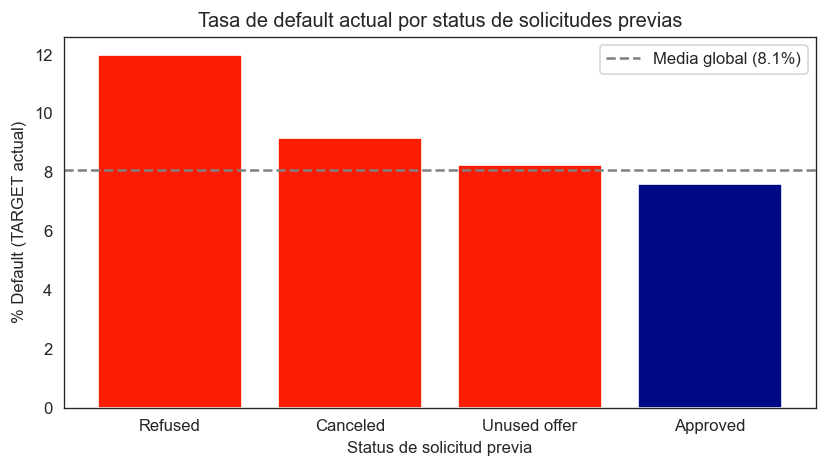

,mean,count,mean_pct
NAME_CONTRACT_STATUS,,,
Refused,0.119964,245390,11.996414
Canceled,0.091736,259441,9.173569
Unused offer,0.082517,22771,8.251724
Approved,0.075887,886099,7.588655


In [5]:
print('NAME_CONTRACT_STATUS — distribución:')
print(prev['NAME_CONTRACT_STATUS'].value_counts())

# % default por status
status_target = prev.merge(train, on='SK_ID_CURR', how='inner')
global_rate = train['TARGET'].mean()

status_stats = status_target.groupby('NAME_CONTRACT_STATUS')['TARGET'].agg(['mean', 'count'])
status_stats['mean_pct'] = status_stats['mean'] * 100
status_stats = status_stats.sort_values('mean', ascending=False)

fig, ax = plt.subplots(figsize=(7, 4))
colors = [COLOR_1 if v > global_rate else COLOR_0 for v in status_stats['mean']]
ax.bar(status_stats.index, status_stats['mean_pct'], color=colors, edgecolor='white')
ax.axhline(global_rate * 100, color='gray', linestyle='--',
           label=f'Media global ({global_rate*100:.1f}%)')
ax.set_xlabel('Status de solicitud previa')
ax.set_ylabel('% Default (TARGET actual)')
ax.set_title('Tasa de default actual por status de solicitudes previas')
ax.legend()
plt.tight_layout()
plt.show()
display(status_stats)

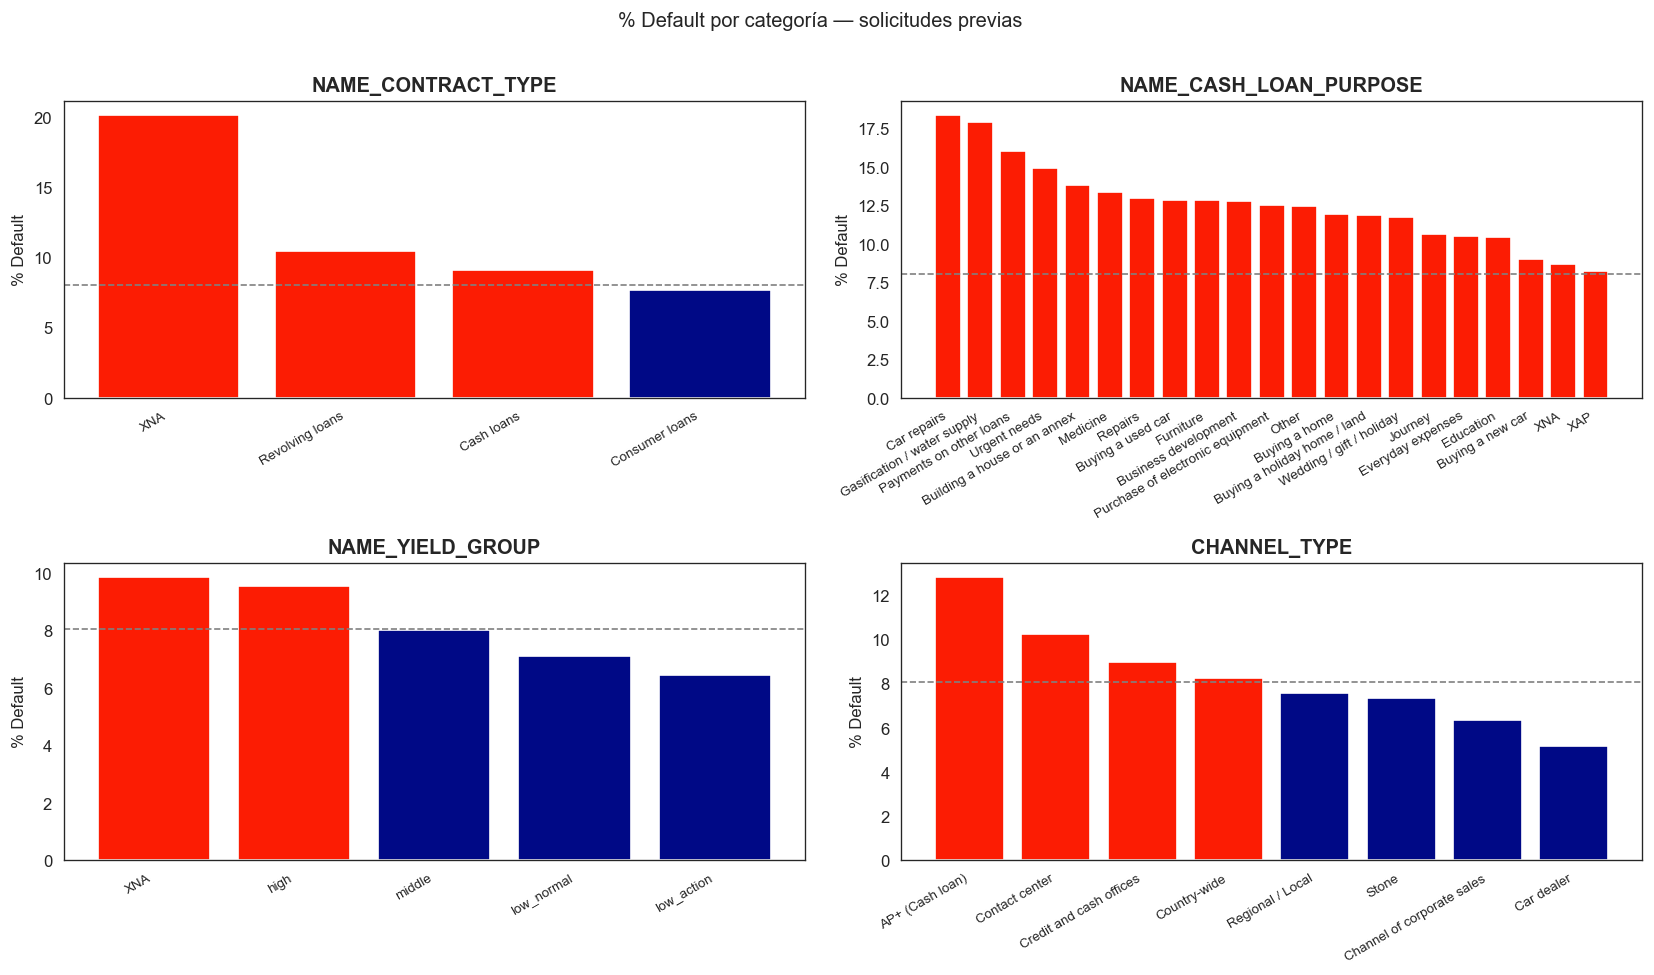

In [6]:
# Otras categóricas vs TARGET
cat_plot = ['NAME_CONTRACT_TYPE', 'NAME_CASH_LOAN_PURPOSE', 'NAME_YIELD_GROUP', 'CHANNEL_TYPE']

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for i, col in enumerate(cat_plot):
    if col not in prev.columns:
        continue
    ax = axes[i]
    tmp = status_target.groupby(col)['TARGET'].agg(['mean', 'count'])
    tmp = tmp[tmp['count'] >= 200].sort_values('mean', ascending=False)
    colors = [COLOR_1 if v > global_rate else COLOR_0 for v in tmp['mean']]
    ax.bar(range(len(tmp)), tmp['mean'] * 100, color=colors, edgecolor='white')
    ax.axhline(global_rate * 100, color='gray', linestyle='--', linewidth=1)
    ax.set_xticks(range(len(tmp)))
    ax.set_xticklabels(tmp.index, rotation=30, ha='right', fontsize=8)
    ax.set_title(col, fontweight='bold')
    ax.set_ylabel('% Default')

plt.suptitle('% Default por categoría — solicitudes previas', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

## 5. Aggregaciones por SK_ID_CURR

In [7]:
# Aggregaciones numéricas
num_agg = {
    'AMT_ANNUITY':        ['mean', 'max'],
    'AMT_APPLICATION':    ['mean', 'max'],
    'AMT_CREDIT':         ['mean', 'sum'],
    'AMT_DOWN_PAYMENT':   ['mean'],
    'AMT_GOODS_PRICE':    ['mean'],
    'RATE_DOWN_PAYMENT':  ['mean'],
    'DAYS_DECISION':      ['mean', 'min'],
    'CNT_PAYMENT':        ['mean', 'sum'],
    'SK_ID_PREV':         ['count'],   # número de solicitudes previas
}

prev_agg = prev.groupby('SK_ID_CURR').agg(num_agg)
prev_agg.columns = ['PREV_' + '_'.join(c).upper() for c in prev_agg.columns]
prev_agg = prev_agg.rename(columns={'PREV_SK_ID_PREV_COUNT': 'PREV_COUNT'})

# Ratio AMT_APPLICATION / AMT_CREDIT por solicitud → luego mean
prev['APP_CREDIT_RATIO'] = prev['AMT_APPLICATION'] / prev['AMT_CREDIT'].replace(0, np.nan)
prev_agg['PREV_APP_CREDIT_RATIO_MEAN'] = prev.groupby('SK_ID_CURR')['APP_CREDIT_RATIO'].mean()

# Approved
approved = prev[prev['NAME_CONTRACT_STATUS'] == 'Approved']
prev_agg['PREV_APPROVED_RATIO'] = (
    approved.groupby('SK_ID_CURR').size() / prev.groupby('SK_ID_CURR').size()
)
prev_agg['PREV_APPROVED_AMT_CREDIT_MEAN'] = approved.groupby('SK_ID_CURR')['AMT_CREDIT'].mean()

# Refused
refused = prev[prev['NAME_CONTRACT_STATUS'] == 'Refused']
prev_agg['PREV_REFUSED_RATIO'] = (
    refused.groupby('SK_ID_CURR').size() / prev.groupby('SK_ID_CURR').size()
)

prev_agg = prev_agg.reset_index()
print(f'Features de previous_application generadas: {prev_agg.shape[1] - 1}')
display(prev_agg.head(3))

Features de previous_application generadas: 18


,SK_ID_CURR,PREV_AMT_ANNUITY_MEAN,PREV_AMT_ANNUITY_MAX,PREV_AMT_APPLICATION_MEAN,PREV_AMT_APPLICATION_MAX,PREV_AMT_CREDIT_MEAN,PREV_AMT_CREDIT_SUM,PREV_AMT_DOWN_PAYMENT_MEAN,PREV_AMT_GOODS_PRICE_MEAN,PREV_RATE_DOWN_PAYMENT_MEAN,PREV_DAYS_DECISION_MEAN,PREV_DAYS_DECISION_MIN,PREV_CNT_PAYMENT_MEAN,PREV_CNT_PAYMENT_SUM,PREV_COUNT,PREV_APP_CREDIT_RATIO_MEAN,PREV_APPROVED_RATIO,PREV_APPROVED_AMT_CREDIT_MEAN,PREV_REFUSED_RATIO
0,100001,3951.000,3951.000,24835.5,24835.5,23787.0,23787.0,2520.0,24835.5,0.104326,-1740.0,-1740,8.0,8.0,1,1.044079,1.0,23787.0,NaN
1,100002,9251.775,9251.775,179055.0,179055.0,179055.0,179055.0,0.0,179055.0,0.000000,-606.0,-606,24.0,24.0,1,1.000000,1.0,179055.0,NaN
2,100003,56553.990,98356.995,435436.5,900000.0,484191.0,1452573.0,3442.5,435436.5,0.050030,-1305.0,-2341,10.0,30.0,3,0.949329,1.0,484191.0,NaN


## 6. Correlación con TARGET

Top 12 features de previous_application más correlacionadas con TARGET:


,feature,corr
0,PREV_REFUSED_RATIO,0.085187
1,PREV_APPROVED_RATIO,-0.064368
2,PREV_DAYS_DECISION_MIN,0.053434
3,PREV_DAYS_DECISION_MEAN,0.046864
4,PREV_APP_CREDIT_RATIO_MEAN,-0.035560
5,PREV_AMT_ANNUITY_MEAN,-0.034871
6,PREV_RATE_DOWN_PAYMENT_MEAN,-0.033601
7,PREV_AMT_ANNUITY_MAX,-0.028966
8,PREV_CNT_PAYMENT_MEAN,0.027743
9,PREV_CNT_PAYMENT_SUM,0.027716


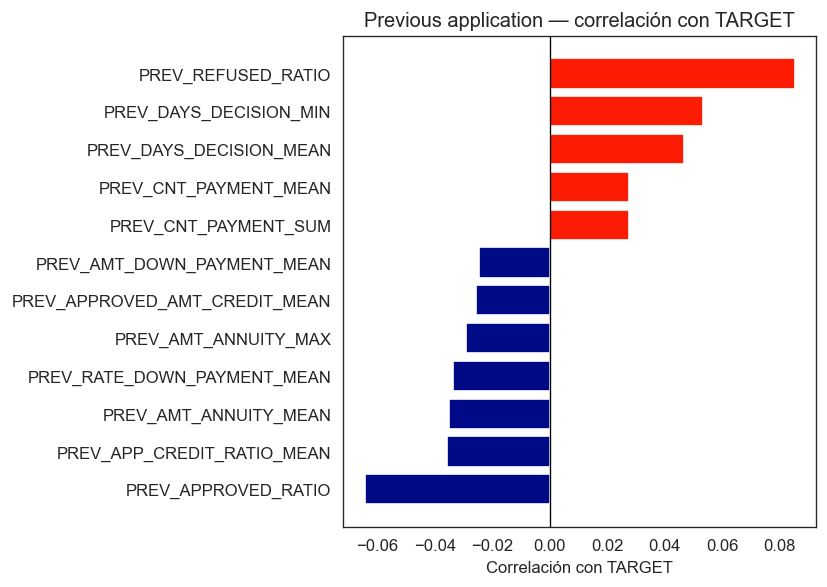

In [8]:
prev_target = prev_agg.merge(train, on='SK_ID_CURR', how='inner')
feat_cols = [c for c in prev_agg.columns if c != 'SK_ID_CURR']

corr_prev = prev_target[feat_cols + ['TARGET']].corrwith(prev_target['TARGET'])
corr_prev = corr_prev.drop('TARGET').sort_values(key=abs, ascending=False)
corr_df = pd.DataFrame({'feature': corr_prev.index, 'corr': corr_prev.values})

print('Top 12 features de previous_application más correlacionadas con TARGET:')
display(corr_df.head(12)[['feature', 'corr']].reset_index(drop=True))

# Gráfico: top12 por abs, luego ordenar por valor raw para gradiente azul→rojo
top12 = corr_df.head(12).sort_values('corr', ascending=True)
fig, ax = plt.subplots(figsize=(7, 5))
colors = [COLOR_0 if c < 0 else COLOR_1 for c in top12['corr']]
ax.barh(top12['feature'], top12['corr'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Correlación con TARGET')
ax.set_title('Previous application — correlación con TARGET')
plt.tight_layout()
plt.show()

## 7. KDE por TARGET — top features

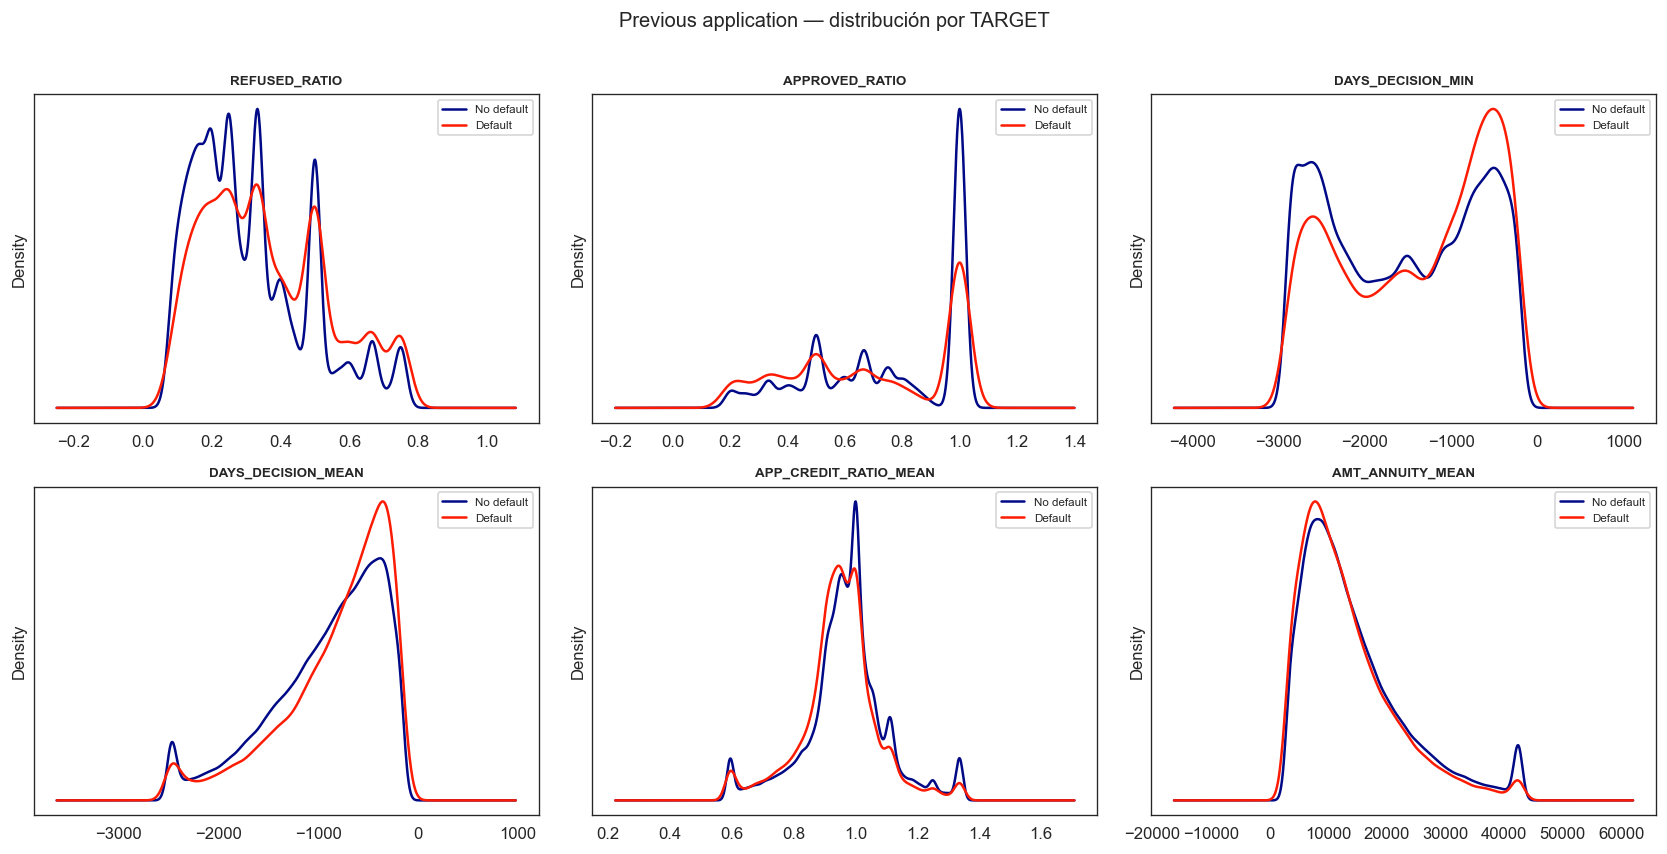

In [9]:
top_feats = corr_df.head(6)['feature'].tolist()
df0 = prev_target[prev_target['TARGET'] == 0]
df1 = prev_target[prev_target['TARGET'] == 1]

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
axes = axes.flatten()

for i, col in enumerate(top_feats):
    ax = axes[i]
    lo = prev_target[col].quantile(0.02)
    hi = prev_target[col].quantile(0.98)
    s0 = df0[col].clip(lo, hi).dropna()
    s1 = df1[col].clip(lo, hi).dropna()
    if len(s0) > 10 and len(s1) > 10:
        s0.plot.kde(ax=ax, color=COLOR_0, label='No default', linewidth=1.5)
        s1.plot.kde(ax=ax, color=COLOR_1, label='Default', linewidth=1.5)
    ax.set_title(col.replace('PREV_', ''), fontsize=8, fontweight='bold')
    ax.set_yticks([])
    ax.legend(fontsize=7)

plt.suptitle('Previous application — distribución por TARGET', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

## 8. Resumen — candidatas de previous_application

In [10]:
print('Features seleccionadas de previous_application para notebook 05:')
selected = [
    ('PREV_COUNT',                   'Número total de solicitudes previas'),
    ('PREV_APPROVED_RATIO',          'Fracción de solicitudes aprobadas'),
    ('PREV_REFUSED_RATIO',           'Fracción de solicitudes rechazadas'),
    ('PREV_APPROVED_AMT_CREDIT_MEAN','Crédito promedio en solicitudes aprobadas'),
    ('PREV_APP_CREDIT_RATIO_MEAN',   'Ratio AMT_APPLICATION/AMT_CREDIT (medio)'),
    ('PREV_DAYS_DECISION_MEAN',      'Días promedio desde la decisión'),
]
for feat, desc in selected:
    corr_match = corr_prev.get(feat, None)
    if corr_match is not None:
        print(f'  {feat:<40s} corr={corr_match:+.4f}  ← {desc}')
    else:
        print(f'  {feat:<40s}  ← {desc}')

Features seleccionadas de previous_application para notebook 05:
  PREV_COUNT                               corr=+0.0198  ← Número total de solicitudes previas
  PREV_APPROVED_RATIO                      corr=-0.0644  ← Fracción de solicitudes aprobadas
  PREV_REFUSED_RATIO                       corr=+0.0852  ← Fracción de solicitudes rechazadas
  PREV_APPROVED_AMT_CREDIT_MEAN            corr=-0.0258  ← Crédito promedio en solicitudes aprobadas
  PREV_APP_CREDIT_RATIO_MEAN               corr=-0.0356  ← Ratio AMT_APPLICATION/AMT_CREDIT (medio)
  PREV_DAYS_DECISION_MEAN                  corr=+0.0469  ← Días promedio desde la decisión


---
**Próximo notebook**: `04_eda_balance_tables.ipynb` — POS_CASH, credit_card e installments.